# TP3 — Data-Centric Design: Análisis de Errores y Estrategia Data-Centered

**Materia:** 72.75 Aprendizaje Automático — ITBA

## Alcance

Este notebook implementa el enfoque **data-centered**: análisis de errores del modelo baseline
por cohortes, curvas de aprendizaje, y mejora del sistema mediante incorporación de datos
reales y data augmentation con SMOTE.

Estructura:
1. **3.1 Análisis de errores por cohorte** — client_type, service_tier, reserved_gpu_type
2. **3.2 Curvas de aprendizaje** — ¿modelo-limitado o datos-limitado?
3. **3.3 Estrategia data-centered** — cohorte problemática seleccionada
4. **3.4 Datos reales vs SMOTE** — comparación de estrategias
5. **4. Modelo final** — evaluación y función predictora

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import pickle

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, cross_validate, learning_curve
)
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
TARGET = "canceled_job"
N_SPLITS = 5
COHORT_COLS = ["client_type", "service_tier", "reserved_gpu_type"]

os.makedirs("outputs", exist_ok=True)

## Carga de datos y modelo baseline

In [22]:
train_df = pd.read_csv("data/processed/train.csv")
test_df  = pd.read_csv("data/processed/test.csv")

with open("data/processed/feature_cols.txt") as f:
    feature_cols = f.read().splitlines()

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET]

# Cargar pipeline entrenado del notebook 02
with open("data/processed/best_pipeline.pkl", "rb") as f:
    best_pipe = pickle.load(f)

with open("data/processed/best_model_info.json") as f:
    best_info = json.load(f)

# Labels de cohortes originales (guardadas en 01_limpieza en orden cronológico)
cohort_labels = pd.read_csv("dataset/cohort_labels.csv", index_col=0)

# Split temporal matching: las últimas 20% filas
split_idx = int(len(cohort_labels) * 0.80)
cohort_test = cohort_labels.iloc[split_idx:].reset_index(drop=True)

print(f"Mejor modelo: {best_info['model_name']}")
print(f"Test F1: {best_info['test_f1']:.4f}  |  Test ROC-AUC: {best_info['test_roc_auc']:.4f}")
print(f"\nCohortes en test: {cohort_test.shape}")

Mejor modelo: XGBoost
Test F1: 0.7185  |  Test ROC-AUC: 0.8772

Cohortes en test: (1911, 3)


In [23]:
# Predicciones en test
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

# DataFrame de análisis: predicciones + cohortes + errores
analysis_df = cohort_test.copy().reset_index(drop=True)
analysis_df["y_true"] = y_test.values
analysis_df["y_pred"] = y_pred
analysis_df["y_prob"] = y_prob
analysis_df["correct"] = (analysis_df["y_true"] == analysis_df["y_pred"]).astype(int)
analysis_df["error_type"] = "TN"  # true negative
analysis_df.loc[(analysis_df.y_true == 0) & (analysis_df.y_pred == 1), "error_type"] = "FP"
analysis_df.loc[(analysis_df.y_true == 1) & (analysis_df.y_pred == 0), "error_type"] = "FN"
analysis_df.loc[(analysis_df.y_true == 1) & (analysis_df.y_pred == 1), "error_type"] = "TP"

print("Error types en test:")
print(analysis_df["error_type"].value_counts())
print(f"\nGlobal: F1={f1_score(y_test, y_pred):.4f}  FP={( (y_pred==1)&(y_test.values==0) ).sum()}  FN={( (y_pred==0)&(y_test.values==1) ).sum()}")

Error types en test:
error_type
TN    1078
TP     467
FN     195
FP     171
Name: count, dtype: int64

Global: F1=0.7185  FP=171  FN=195


## 3.1 Análisis de errores por cohorte

Evaluamos el rendimiento del modelo en subgrupos definidos por `client_type`, `service_tier`
y `reserved_gpu_type`. Calculamos F1, tasa de FP y tasa de FN por cohorte.

In [24]:
def cohort_metrics(df, cohort_col):
    """Calculates F1, FPR, FNR per cohort value."""
    rows = []
    for group, gdf in df.groupby(cohort_col):
        n = len(gdf)
        yt = gdf["y_true"].values
        yp = gdf["y_pred"].values
        tp = ((yt == 1) & (yp == 1)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        f1 = f1_score(yt, yp, zero_division=0)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        cancel_rate = yt.mean()
        rows.append({
            "cohort": group, "n": n, "cancel_rate": round(cancel_rate, 3),
            "F1": round(f1, 4), "FPR": round(fpr, 4), "FNR": round(fnr, 4),
            "TP": tp, "FP": fp, "FN": fn, "TN": tn
        })
    return pd.DataFrame(rows).sort_values("F1")

cohort_results = {col: cohort_metrics(analysis_df, col) for col in COHORT_COLS}

for col, cdf in cohort_results.items():
    print(f"\n=== {col} ===")
    print(cdf.to_string(index=False))


=== client_type ===
               cohort   n  cancel_rate     F1    FPR    FNR  TP  FP  FN  TN
high_priority_partner   4        0.250 0.0000 0.0000 1.0000   0   0   1   3
    sponsored_project  20        0.050 0.0000 0.1053 1.0000   0   2   1  17
    enterprise_client 119        0.143 0.2857 0.0686 0.7647   4   7  13  95
    internal_research 183        0.120 0.3077 0.0683 0.7273   6  11  16 150
    cloud_marketplace 804        0.320 0.5993 0.2139 0.3774 160 117  97 430
      managed_account 446        0.363 0.8350 0.0387 0.2346 124  11  38 273
  research_consortium 335        0.603 0.8693 0.1729 0.1436 173  23  29 110

=== service_tier ===
    cohort    n  cancel_rate     F1    FPR    FNR  TP  FP  FN  TN
   unknown   27        0.074 0.0000 0.1600 1.0000   0   4   2  21
 on_demand  134        0.343 0.6292 0.1705 0.3913  28  15  18  73
  standard 1539        0.346 0.7094 0.1412 0.3039 371 142 162 864
  priority  193        0.352 0.8444 0.0800 0.1618  57  10  11 115
enterprise   18    

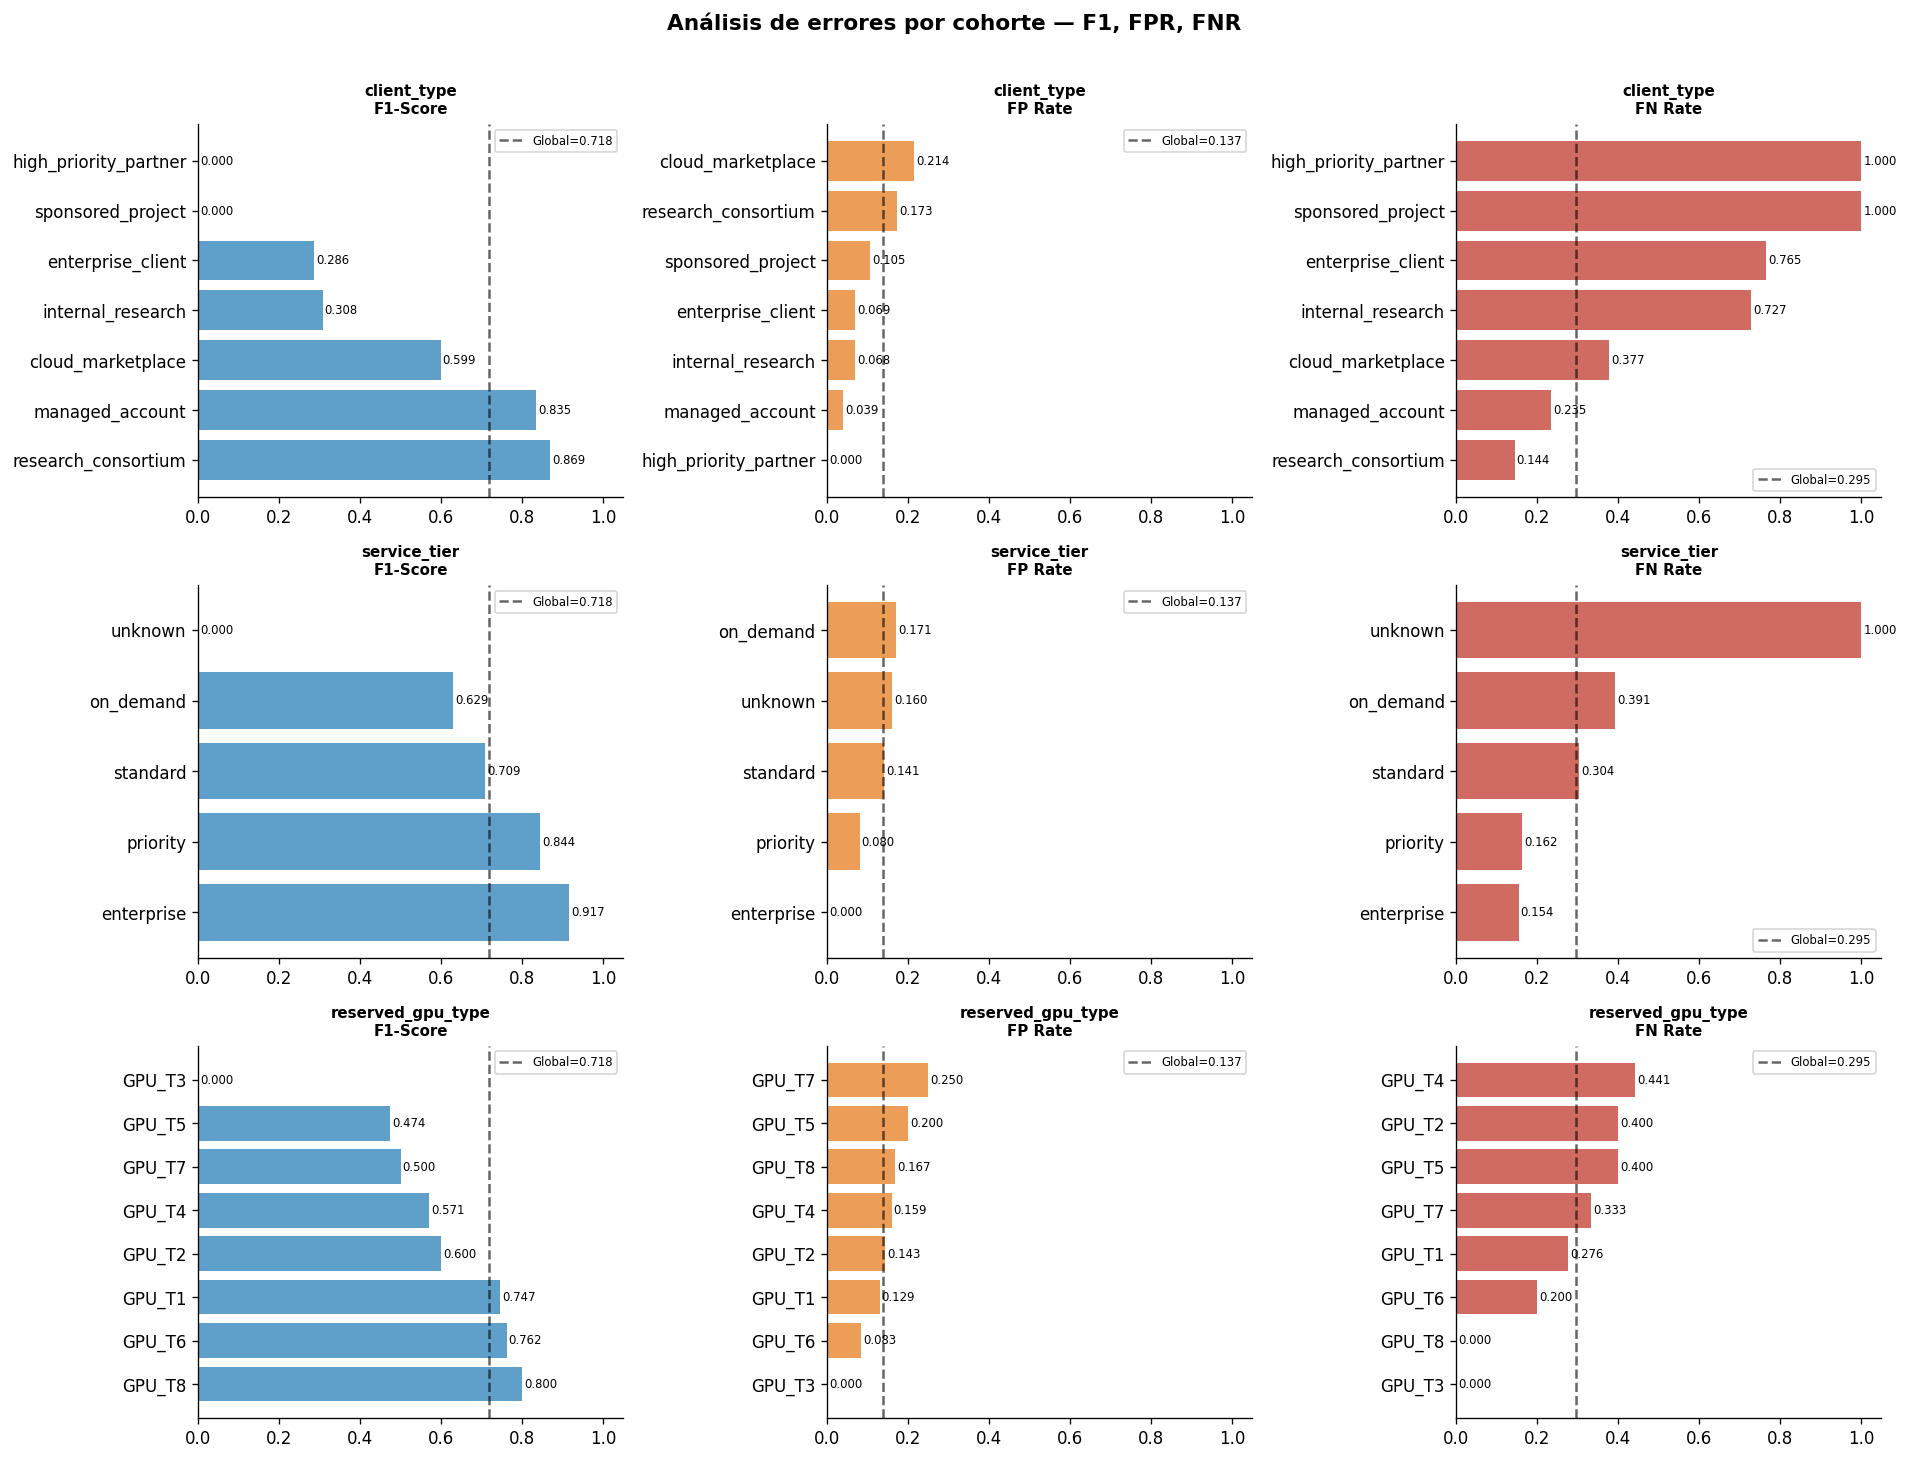

In [25]:
fig, axes = plt.subplots(len(COHORT_COLS), 3, figsize=(16, len(COHORT_COLS) * 4))
fig.suptitle("Análisis de errores por cohorte — F1, FPR, FNR", fontsize=13, fontweight="bold", y=1.01)

global_f1  = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
global_fpr = fp / (fp + tn)
global_fnr = fn / (fn + tp)

for row, col in enumerate(COHORT_COLS):
    cdf = cohort_results[col]
    ax_f1, ax_fpr, ax_fnr = axes[row]

    for ax, metric, ref, color, title in [
        (ax_f1,  "F1",  global_f1,  "#2980B9", "F1-Score"),
        (ax_fpr, "FPR", global_fpr, "#E67E22", "FP Rate"),
        (ax_fnr, "FNR", global_fnr, "#C0392B", "FN Rate"),
    ]:
        cdf_sorted = cdf.sort_values(metric, ascending=(metric != "F1"))
        bars = ax.barh(cdf_sorted["cohort"], cdf_sorted[metric], color=color, alpha=0.75)
        ax.axvline(ref, color="black", linestyle="--", alpha=0.6, label=f"Global={ref:.3f}")
        for bar, val in zip(bars, cdf_sorted[metric]):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f"{val:.3f}", va="center", fontsize=7)
        ax.set_title(f"{col}\n{title}", fontsize=9, fontweight="bold")
        ax.set_xlim(0, 1.05)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("outputs/cohort_error_analysis.png", bbox_inches="tight")
plt.show()

In [26]:
# Identificar cohorte más problemática
print("=== COHORTES MÁS PROBLEMÁTICAS (menor F1) ===")
for col in COHORT_COLS:
    worst = cohort_results[col].iloc[0]  # ya ordenado por F1 ascendente
    print(f"\n{col}: '{worst['cohort']}' — F1={worst['F1']:.4f}, FNR={worst['FNR']:.4f}, n={worst['n']}, cancel_rate={worst['cancel_rate']:.2%}")
    if worst['F1'] < global_f1 * 0.8:
        print(f"  Rendimiento significativamente bajo el promedio global ({global_f1:.4f})")

=== COHORTES MÁS PROBLEMÁTICAS (menor F1) ===

client_type: 'high_priority_partner' — F1=0.0000, FNR=1.0000, n=4, cancel_rate=25.00%
  Rendimiento significativamente bajo el promedio global (0.7185)

service_tier: 'unknown' — F1=0.0000, FNR=1.0000, n=27, cancel_rate=7.40%
  Rendimiento significativamente bajo el promedio global (0.7185)

reserved_gpu_type: 'GPU_T3' — F1=0.0000, FNR=0.0000, n=5, cancel_rate=0.00%
  Rendimiento significativamente bajo el promedio global (0.7185)


## 3.2 Curvas de aprendizaje

Analizamos cómo evoluciona el rendimiento al aumentar la cantidad de datos de entrenamiento.
Esto permite determinar si el sistema está **limitado por el modelo** (alto bias) o
**limitado por los datos** (alta varianza).

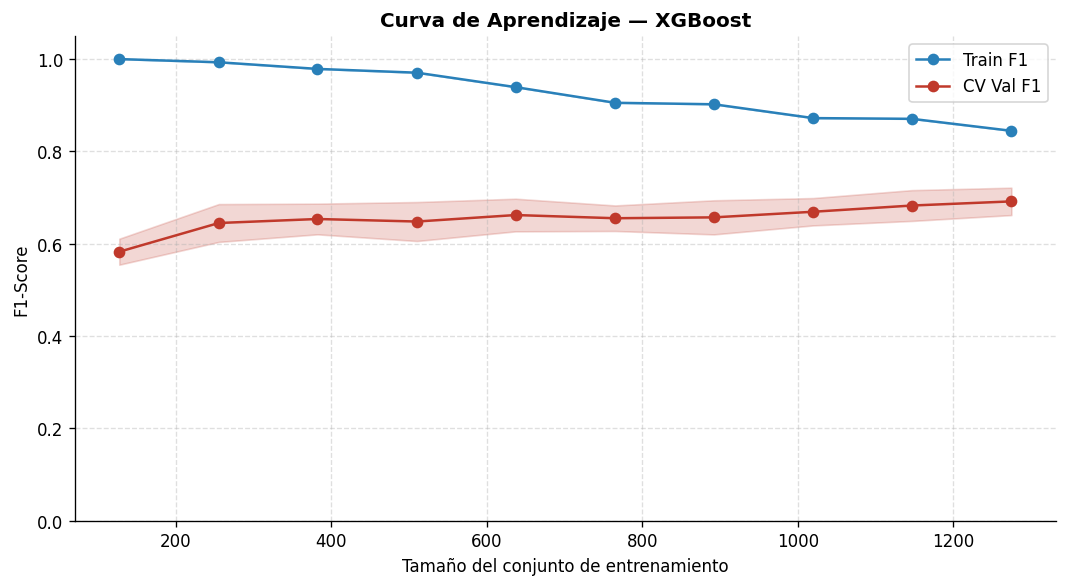

Gap Train-Val con 100% datos: 0.1529
Mejora en val (50%→100% datos): 0.0382
→ Alto overfitting: el modelo podría beneficiarse de regularización o más datos


In [27]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train,
    cv=tscv,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=2
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#2980B9", label="Train F1")
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.2, color="#2980B9")

ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="#C0392B", label="CV Val F1")
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.2, color="#C0392B")

ax.set_xlabel("Tamaño del conjunto de entrenamiento")
ax.set_ylabel("F1-Score")
ax.set_title(f"Curva de Aprendizaje — {best_info['model_name']}", fontweight="bold")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("outputs/learning_curve.png", bbox_inches="tight")
plt.show()

# Análisis del gap
final_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
val_trend  = val_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[len(val_scores[0])//2]
print(f"Gap Train-Val con 100% datos: {final_gap:.4f}")
print(f"Mejora en val (50%→100% datos): {val_trend:.4f}")
if final_gap > 0.15:
    print("→ Alto overfitting: el modelo podría beneficiarse de regularización o más datos")
elif val_trend > 0.02:
    print("→ La curva de val aún crece: el sistema es DATOS-LIMITADO, más datos ayudarían")
else:
    print("→ La curva de val se aplana: el sistema es MODELO-LIMITADO, más datos no ayudarán mucho")


## 3.3 Estrategia data-centered

### Selección de cohorte problemática

A partir del análisis de errores (3.1) seleccionamos una cohorte problemática para la
intervención data-centered, priorizando bajo F1, tamaño de la cohorte (impacto operativo)
y disponibilidad de datos adicionales reales.

In [28]:
# Tabla resumen de todas las cohortes, ordenadas por F1
all_cohorts = []
for col in COHORT_COLS:
    cdf = cohort_results[col].copy()
    cdf["dimension"] = col
    all_cohorts.append(cdf)

all_cohorts_df = pd.concat(all_cohorts).sort_values("F1").reset_index(drop=True)
print("Todas las cohortes ordenadas por F1 (peor primero):")
print(all_cohorts_df[["dimension", "cohort", "n", "cancel_rate", "F1", "FPR", "FNR"]].to_string(index=False))

Todas las cohortes ordenadas por F1 (peor primero):
        dimension                cohort    n  cancel_rate     F1    FPR    FNR
      client_type high_priority_partner    4        0.250 0.0000 0.0000 1.0000
      client_type     sponsored_project   20        0.050 0.0000 0.1053 1.0000
     service_tier               unknown   27        0.074 0.0000 0.1600 1.0000
reserved_gpu_type                GPU_T3    5        0.000 0.0000 0.0000 0.0000
      client_type     enterprise_client  119        0.143 0.2857 0.0686 0.7647
      client_type     internal_research  183        0.120 0.3077 0.0683 0.7273
reserved_gpu_type                GPU_T5   85        0.176 0.4737 0.2000 0.4000
reserved_gpu_type                GPU_T7   15        0.200 0.5000 0.2500 0.3333
reserved_gpu_type                GPU_T4  238        0.286 0.5714 0.1588 0.4412
      client_type     cloud_marketplace  804        0.320 0.5993 0.2139 0.3774
reserved_gpu_type                GPU_T2   19        0.263 0.6000 0.1429 0.4000


In [29]:
# Seleccion automatica: peor F1 con n>=30
relevant_cohorts = all_cohorts_df[all_cohorts_df["n"] >= 30]
auto_pick = relevant_cohorts.iloc[0]
print(f"Seleccion automatica (peor F1, n>=30): {auto_pick['dimension']}='{auto_pick['cohort']}' "
      f"(F1={auto_pick['F1']:.4f}, n={auto_pick['n']})\n")

# Override manual: intervenimos internal_research en lugar del peor F1 (enterprise_client).
# Es la cohorte problematica mas grande (10.6% del dataset vs 4.4%), su F1 esta a 0.02 del peor,
# y es la unica con datos reales adicionales disponibles para comparar contra SMOTE/class_weight.
SELECTED_COHORT_DIM   = "client_type"
SELECTED_COHORT_VALUE = "internal_research"

worst_cohort_row = all_cohorts_df[
    (all_cohorts_df["dimension"] == SELECTED_COHORT_DIM) &
    (all_cohorts_df["cohort"] == SELECTED_COHORT_VALUE)
].iloc[0]

print(f"Cohorte seleccionada para intervención:")
print(f"  Dimensión:   {SELECTED_COHORT_DIM}")
print(f"  Valor:       {SELECTED_COHORT_VALUE}")
print(f"  F1 en test:  {worst_cohort_row['F1']:.4f} (global: {global_f1:.4f})")
print(f"  FNR:         {worst_cohort_row['FNR']:.4f}")
print(f"  N en test:   {worst_cohort_row['n']}")
print(f"  Cancel rate: {worst_cohort_row['cancel_rate']:.2%}")

# Tamaño de la cohorte en train
cohort_train = cohort_labels.iloc[:int(len(cohort_labels)*0.80)]
n_cohort_train = (cohort_train[SELECTED_COHORT_DIM] == SELECTED_COHORT_VALUE).sum()
print(f"\nEn train: {n_cohort_train} instancias de '{SELECTED_COHORT_VALUE}' "
      f"({100*n_cohort_train/len(cohort_train):.1f}% del train)")

Seleccion automatica (peor F1, n>=30): client_type='enterprise_client' (F1=0.2857, n=119)

Cohorte seleccionada para intervención:
  Dimensión:   client_type
  Valor:       internal_research
  F1 en test:  0.3077 (global: 0.7185)
  FNR:         0.7273
  N en test:   183
  Cancel rate: 12.00%

En train: 826 instancias de 'internal_research' (10.8% del train)


### Discusión: frecuencia, impacto y causas posibles

- **Frecuencia:** `internal_research` es el 10.6% del dataset (la cohorte problemática más
  grande), con 826 instancias en train.
- **Impacto:** F1=0.31 en test (vs 0.72 global) y FNR=0.73; el modelo no detecta la mayoría
  de las cancelaciones reales de esta cohorte.
- **Causas posibles:** tasa de cancelación baja (12% vs 37% global) → clase positiva
  subrepresentada dentro de la cohorte, sumado a un patrón de cancelación distinto al del
  resto del dataset.

In [30]:
# Distribución de la cohorte seleccionada en todo el dataset original
df_orig = pd.read_csv("dataset/gpu_resource_reservations.csv")
cohort_full = df_orig[df_orig[SELECTED_COHORT_DIM] == SELECTED_COHORT_VALUE]

print(f"\n=== Cohorte '{SELECTED_COHORT_VALUE}' — análisis completo ===")
print(f"Total instancias en dataset: {len(cohort_full)} ({100*len(cohort_full)/len(df_orig):.1f}%)")
print(f"Tasa de cancelación: {cohort_full['canceled_job'].mean():.2%} (global: {df_orig['canceled_job'].mean():.2%})")
print(f"\nDistribución por mes:")
print(cohort_full.groupby("request_month")["canceled_job"].agg(["mean", "count"]).round(3).to_string())


=== Cohorte 'internal_research' — análisis completo ===
Total instancias en dataset: 1009 (10.6%)
Tasa de cancelación: 15.36% (global: 37.04%)

Distribución por mes:
                mean  count
request_month              
1              0.085     71
2              0.075     93
3              0.083     84
4              0.129     62
5              0.214     70
6              0.154     78
7              0.228    127
8              0.224    152
9              0.155     84
10             0.097     72
11             0.167     54
12             0.129     62


## 3.4 Adquisición de datos vs SMOTE

Comparamos tres estrategias para mejorar el rendimiento en la cohorte problemática:
- **Path A: Datos reales** — incorporar al train el dataset adicional de la cohorte.
- **Path B: SMOTE** — generar instancias sintéticas de la cohorte por interpolación.
- **Path C: class_weight** — aumentar el peso de la cohorte en el entrenamiento sin generar datos.

Path C es la opción más conservadora cuando hay pocos positivos en la cohorte (133 en train):
SMOTE sobre pocas muestras puede generar artefactos, mientras que el reponderado solo aumenta
la influencia de las muestras reales existentes.

In [31]:
# Cargar dataset adicional si existe, sino usar placeholder
EXTRA_DATA_PATH = f"dataset/cohort_extra_{SELECTED_COHORT_VALUE.lower().replace(' ', '_')}.csv"

has_extra_data = os.path.exists(EXTRA_DATA_PATH)


def preprocess_like_notebook01(df_raw):
    """Replica el preprocessing de 01_limpieza sobre datos crudos: drop de columnas derivadas,
    encoding ciclico de request_week y OHE, alineando al espacio de `feature_cols`.

    OHE con drop_first=False + reindex (no drop_first=True): sobre un subconjunto de una sola
    categoria, drop_first eliminaria su dummy y la codificaria mal. El reindex es equivalente
    al encoding de train para cualquier fila.
    """
    d = df_raw.copy()
    for col in ["total_gpu_hours", "total_processes", "request_month"]:
        if col in d.columns:
            d = d.drop(columns=[col])
    d["week_sin"] = np.sin(2 * np.pi * d["request_week"] / 53)
    d["week_cos"] = np.cos(2 * np.pi * d["request_week"] / 53)
    cat_cols = d.select_dtypes(include="object").columns.tolist()
    d = pd.get_dummies(d, columns=cat_cols, drop_first=False, dtype=int)
    return d.reindex(columns=feature_cols, fill_value=0)


if has_extra_data:
    print(f"Dataset adicional encontrado: {EXTRA_DATA_PATH}")
    df_extra_raw = pd.read_csv(EXTRA_DATA_PATH)
    print(f"  Shape: {df_extra_raw.shape}")
    print("  Aplicando mismo preprocessing que en notebook 01...")

    y_extra = df_extra_raw[TARGET].reset_index(drop=True)
    X_extra = preprocess_like_notebook01(df_extra_raw.drop(columns=[TARGET]))

    # Sanity checks: features alineadas y que el extra sea de la cohorte esperada
    assert list(X_extra.columns) == feature_cols, "Las columnas no coinciden con el modelo"
    pct_cohort = (df_extra_raw[SELECTED_COHORT_DIM] == SELECTED_COHORT_VALUE).mean()
    cohort_mask_train = (cohort_labels.iloc[:int(len(cohort_labels)*0.80)][SELECTED_COHORT_DIM].values
                         == SELECTED_COHORT_VALUE)
    print(f"  Procesado OK: X_extra={X_extra.shape} (features alineadas)")
    print(f"  % de la cohorte '{SELECTED_COHORT_VALUE}' en el extra: {pct_cohort:.0%}")
    print(f"  cancel_rate extra: {y_extra.mean():.2%}  |  cancel_rate cohorte en train: "
          f"{y_train[cohort_mask_train].mean():.2%}")
else:
    print(f"Dataset adicional NO encontrado en {EXTRA_DATA_PATH}")
    print("Usando bootstrap de las instancias existentes de la cohorte como PLACEHOLDER.")
    print("Reemplazar con el dataset real cuando esté disponible.")

    # Placeholder: bootstrap de la cohorte en train
    cohort_train_labels = cohort_labels.iloc[:int(len(cohort_labels)*0.80)]
    cohort_mask_train = (cohort_train_labels[SELECTED_COHORT_DIM].values == SELECTED_COHORT_VALUE)
    X_cohort = X_train[cohort_mask_train]
    y_cohort = y_train[cohort_mask_train]

    print(f"\nInstancias de la cohorte en train: {len(X_cohort)}")
    print(f"(Bootstrap de estas para simular datos adicionales)")

Dataset adicional encontrado: dataset/cohort_extra_internal_research.csv
  Shape: (500, 29)
  Aplicando mismo preprocessing que en notebook 01...
  Procesado OK: X_extra=(500, 55) (features alineadas)
  % de la cohorte 'internal_research' en el extra: 100%
  cancel_rate extra: 18.20%  |  cancel_rate cohorte en train: 16.10%


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate

best_clf_obj = best_pipe.named_steps["clf"]
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

def make_pipe():
    params = best_clf_obj.get_params()
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", best_clf_obj.__class__(**params))
    ])

def evaluate_strategy_cv(pipe, X_tr, y_tr, label=""):
    """Compara estrategias con TimeSeriesSplit CV (sin snooping en test)."""
    cv_res = cross_validate(pipe, X_tr, y_tr, cv=tscv,
                           scoring={"f1": "f1", "roc_auc": "roc_auc"},
                           return_train_score=True, n_jobs=2)
    f1_mean  = cv_res["test_f1"].mean()
    f1_std   = cv_res["test_f1"].std()
    auc_mean = cv_res["test_roc_auc"].mean()
    auc_std  = cv_res["test_roc_auc"].std()
    print(f"[{label}] CV F1={f1_mean:.4f}±{f1_std:.4f}  CV ROC-AUC={auc_mean:.4f}±{auc_std:.4f}")
    return {"label": label, "CV_F1": f1_mean, "CV_F1_std": f1_std,
            "CV_ROC-AUC": auc_mean, "CV_ROC-AUC_std": auc_std}

results_comparison = []

# Baseline (CV — sin usar test)
r0 = evaluate_strategy_cv(make_pipe(), X_train, y_train, "Baseline")
results_comparison.append(r0)


[Baseline] CV F1=0.7228±0.0222  CV ROC-AUC=0.8604±0.0214


In [33]:
# === PATH A: Datos reales (o placeholder bootstrap) ===
if has_extra_data:
    # Datos reales adicionales, ya preprocesados a feature_cols
    X_augmented_real = pd.concat([X_train, X_extra], ignore_index=True)
    y_augmented_real = pd.concat([y_train, y_extra], ignore_index=True)
    print(f"Path A (datos reales): Train original={len(X_train)} → con extra={len(X_augmented_real)} "
          f"(+{len(X_extra)} instancias reales de '{SELECTED_COHORT_VALUE}')")
else:
    # Placeholder: bootstrap de la cohorte hasta 2x su tamaño (max 500)
    np.random.seed(RANDOM_STATE)
    n_extra = min(len(X_cohort) * 2, 500)
    boot_idx = np.random.choice(len(X_cohort), size=n_extra, replace=True)
    X_extra = X_cohort.iloc[boot_idx].reset_index(drop=True)
    y_extra = y_cohort.iloc[boot_idx].reset_index(drop=True)

    X_augmented_real = pd.concat([X_train, X_extra], ignore_index=True)
    y_augmented_real = pd.concat([y_train, y_extra], ignore_index=True)

    print(f"Path A (placeholder): Train original={len(X_train)} → con extra={len(X_augmented_real)}")

r1 = evaluate_strategy_cv(
    make_pipe(), X_augmented_real, y_augmented_real,
    f"Path A: +datos reales (n={len(X_extra)} extras)"
)
results_comparison.append(r1)


Path A (datos reales): Train original=7640 → con extra=8140 (+500 instancias reales de 'internal_research')
[Path A: +datos reales (n=500 extras)] CV F1=0.6993±0.0211  CV ROC-AUC=0.8561±0.0108


In [34]:
# === Path C: class_weight / scale_pos_weight (alternativa sin SMOTE) ===
# En lugar de generar datos sinteticos, ajustamos los pesos del modelo
# para que de mas importancia a las muestras de la cohorte problematica
# Nota: cross_validate no soporta sample_weight directamente, asi que usamos
# un pipeline wrapper que lo inyecta via fit_params
try:
    from xgboost import XGBClassifier
    IS_XGB = isinstance(best_pipe.named_steps["clf"], XGBClassifier)
except ImportError:
    IS_XGB = False

cohort_train_labels = cohort_labels.iloc[:int(len(cohort_labels)*0.80)]
cohort_mask_train = (cohort_train_labels[SELECTED_COHORT_DIM].values == SELECTED_COHORT_VALUE)

# Crear sample_weight: darle mas peso a la cohorte problematica
sample_weights = np.ones(len(X_train))
COHORT_WEIGHT = 3.0  # triplicar la importancia de la cohorte
sample_weights[cohort_mask_train] = COHORT_WEIGHT

# Path C: evaluar con CV usando sample_weight via fit_params
pipe_weighted = make_pipe()
try:
    cv_res_w = cross_validate(
        pipe_weighted, X_train, y_train, cv=tscv,
        scoring={"f1": "f1", "roc_auc": "roc_auc"},
        return_train_score=True, n_jobs=2,
        params={"clf__sample_weight": sample_weights}
    )
    f1_w_mean  = cv_res_w["test_f1"].mean()
    f1_w_std   = cv_res_w["test_f1"].std()
    auc_w_mean = cv_res_w["test_roc_auc"].mean()
    auc_w_std  = cv_res_w["test_roc_auc"].std()
    print(f"[Path C: class_weight (x{COHORT_WEIGHT})] CV F1={f1_w_mean:.4f}±{f1_w_std:.4f}  CV ROC-AUC={auc_w_mean:.4f}±{auc_w_std:.4f}")
    results_comparison.append({"label": f"Path C: pesos x{COHORT_WEIGHT}",
                              "CV_F1": f1_w_mean, "CV_F1_std": f1_w_std,
                              "CV_ROC-AUC": auc_w_mean, "CV_ROC-AUC_std": auc_w_std})
except Exception as e:
    print(f"Path C no soportado por este clasificador: {e}")

print()

# === PATH B: SMOTE ===
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imblearn no instalado. Ejecutar: pip install imbalanced-learn")

if SMOTE_AVAILABLE:
    # Aplicar SMOTE solo a las instancias de la cohorte problemática en train
    cohort_train_labels = cohort_labels.iloc[:int(len(cohort_labels)*0.80)]
    cohort_mask_train = (cohort_train_labels[SELECTED_COHORT_DIM].values == SELECTED_COHORT_VALUE)

    X_cohort_only  = X_train[cohort_mask_train]
    y_cohort_only  = y_train[cohort_mask_train]
    X_rest = X_train[~cohort_mask_train]
    y_rest = y_train[~cohort_mask_train]

    print(f"Cohorte en train: {len(X_cohort_only)} filas | Clase 0: {(y_cohort_only==0).sum()} | Clase 1: {(y_cohort_only==1).sum()}")

    # SMOTE requiere al menos k+1 instancias de la clase minoritaria
    min_class_count = min(y_cohort_only.value_counts())
    k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1

    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
    X_cohort_smote, y_cohort_smote = smote.fit_resample(X_cohort_only, y_cohort_only)

    # Combinar cohorte aumentada con el resto del train
    X_augmented_smote = pd.concat([
        X_rest.reset_index(drop=True),
        pd.DataFrame(X_cohort_smote, columns=X_train.columns)
    ], ignore_index=True)
    y_augmented_smote = pd.concat([
        y_rest.reset_index(drop=True),
        pd.Series(y_cohort_smote)
    ], ignore_index=True)

    n_synthetic = len(X_cohort_smote) - len(X_cohort_only)
    print(f"SMOTE generó {n_synthetic} instancias sintéticas para la cohorte")
    print(f"Train original={len(X_train)} → con SMOTE={len(X_augmented_smote)}")

    r2 = evaluate_strategy_cv(
        make_pipe(), X_augmented_smote, y_augmented_smote,
        f"Path B: SMOTE (+{n_synthetic} sintéticos)"
    )
    results_comparison.append(r2)


[Path C: class_weight (x3.0)] CV F1=0.7198±0.0304  CV ROC-AUC=0.8581±0.0241

Cohorte en train: 826 filas | Clase 0: 693 | Clase 1: 133
SMOTE generó 560 instancias sintéticas para la cohorte
Train original=7640 → con SMOTE=8200
[Path B: SMOTE (+560 sintéticos)] CV F1=0.7171±0.0459  CV ROC-AUC=0.8591±0.0225



Comparación de estrategias (TimeSeriesSplit CV):
                               label    CV_F1  CV_ROC-AUC
                            Baseline 0.722826    0.860376
Path A: +datos reales (n=500 extras) 0.699277    0.856106
                  Path C: pesos x3.0 0.719774    0.858104
     Path B: SMOTE (+560 sintéticos) 0.717067    0.859146


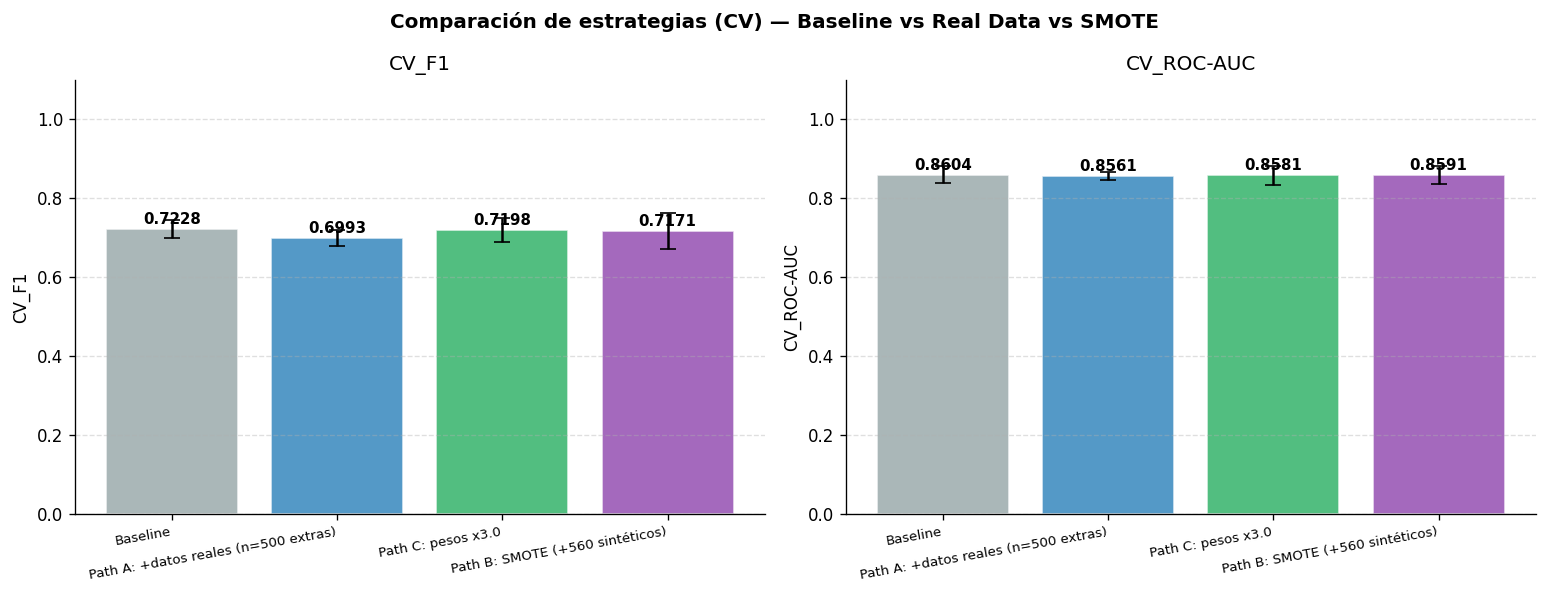

In [35]:
# Comparación visual: Baseline vs Real data vs SMOTE (CV — sin snooping en test)
comp_df = pd.DataFrame(results_comparison)
print("\nComparación de estrategias (TimeSeriesSplit CV):")
print(comp_df[["label", "CV_F1", "CV_ROC-AUC"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Comparación de estrategias (CV) — Baseline vs Real Data vs SMOTE", fontsize=12, fontweight="bold")

x = np.arange(len(comp_df))
for ax, metric, metric_std, color_list in [
    (axes[0], "CV_F1", "CV_F1_std", ["#95A5A6", "#2980B9", "#27AE60", "#8E44AD"]),
    (axes[1], "CV_ROC-AUC", "CV_ROC-AUC_std", ["#95A5A6", "#2980B9", "#27AE60", "#8E44AD"]),
]:
    vals = comp_df[metric]
    errs = comp_df[metric_std]
    bars = ax.bar(x, vals, yerr=errs, color=color_list[:len(comp_df)], alpha=0.8, edgecolor="white", capsize=5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(comp_df["label"], rotation=10, ha="right", fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/real_vs_smote_comparison.png", bbox_inches="tight")
plt.show()


In [36]:
# Análisis diagnóstitico por cohorte tras SMOTE (no usado para selección de modelo)
# Se entrena un modelo en datos SMOTE para entender el efecto por cohorte
if SMOTE_AVAILABLE:
    pipe_smote = make_pipe()
    pipe_smote.fit(X_augmented_smote, y_augmented_smote)
    y_pred_smote = pipe_smote.predict(X_test)
    
    analysis_smote = cohort_test.copy().reset_index(drop=True)
    analysis_smote["y_true"] = y_test.values
    analysis_smote["y_pred"] = y_pred_smote
    
    print("F1 por cohorte — Baseline vs SMOTE (diagnóstico, no para selección):")
    for col in COHORT_COLS:
        base_m = cohort_metrics(analysis_df, col)[["cohort", "F1"]].rename(columns={"F1": "F1_baseline"})
        smote_m = cohort_metrics(analysis_smote, col)[["cohort", "F1"]].rename(columns={"F1": "F1_smote"})
        merged = base_m.merge(smote_m, on="cohort")
        merged["delta"] = (merged["F1_smote"] - merged["F1_baseline"]).round(4)
        print(f"\n  {col}:")
        print(merged.sort_values("delta", ascending=False).to_string(index=False))


F1 por cohorte — Baseline vs SMOTE (diagnóstico, no para selección):

  client_type:
               cohort  F1_baseline  F1_smote   delta
    enterprise_client       0.2857    0.3333  0.0476
      managed_account       0.8350    0.8454  0.0104
    cloud_marketplace       0.5993    0.6066  0.0073
  research_consortium       0.8693    0.8762  0.0069
high_priority_partner       0.0000    0.0000  0.0000
    sponsored_project       0.0000    0.0000  0.0000
    internal_research       0.3077    0.2821 -0.0256

  service_tier:
    cohort  F1_baseline  F1_smote   delta
enterprise       0.9167    0.9231  0.0064
   unknown       0.0000    0.0000  0.0000
  standard       0.7094    0.7081 -0.0013
 on_demand       0.6292    0.5977 -0.0315
  priority       0.8444    0.8058 -0.0386

  reserved_gpu_type:
cohort  F1_baseline  F1_smote   delta
GPU_T7       0.5000    0.5714  0.0714
GPU_T2       0.6000    0.6667  0.0667
GPU_T5       0.4737    0.5143  0.0406
GPU_T4       0.5714    0.5816  0.0102
GPU_T3    

### Discusión: datos reales vs sintéticos

| Aspecto | Datos reales | SMOTE |
|---------|-------------|-------|
| **Distribución** | Refleja el dominio real | Interpolación en espacio de features |
| **Ruido** | Ruido real (diagnóstico, medición) | Sin ruido de dominio |
| **Costo** | Alto (recolección, etiquetado) | Bajo (solo CPU) |
| **Riesgo** | Distribución puede diferir (sesgo de cohorte) | Puede generar interpolaciones no realistas |
| **Mejora global** | Puede mejorar o perjudicar si hay distributional shift | Mejora local en cohorte; riesgo de sobreajuste |

**Situaciones donde pueden empeorar:**
- SMOTE: si la cohorte tiene estructura multimodal, la interpolación cruza modos distintos
- Datos reales extra: si provienen de un período temporal diferente (distributional shift)

## 4. Modelo final

Seleccionamos la estrategia final basada en los resultados de comparación.

In [37]:
# Seleccionar mejor estrategia por CV F1 (sin snooping en test)
best_strategy = max(results_comparison, key=lambda r: r["CV_F1"])
print(f"Mejor estrategia (por CV F1): {best_strategy['label']}")
print(f"  CV F1:      {best_strategy['CV_F1']:.4f}±{best_strategy['CV_F1_std']:.4f}")
print(f"  CV ROC-AUC: {best_strategy['CV_ROC-AUC']:.4f}±{best_strategy['CV_ROC-AUC_std']:.4f}")

# Determinar X_final, y_final según estrategia ganadora
strategy_idx = [r["label"] for r in results_comparison].index(best_strategy["label"])
if strategy_idx == 0:
    X_final, y_final = X_train, y_train
    final_label = "Baseline"
elif strategy_idx == 1:
    X_final, y_final = X_augmented_real, y_augmented_real
    final_label = "Path A: +datos reales"
else:
    X_final, y_final = X_augmented_smote, y_augmented_smote
    final_label = "Path B: SMOTE"

print(f"\nEntrenando modelo final con estrategia: {final_label}")
final_pipe = make_pipe()
final_pipe.fit(X_final, y_final)


Mejor estrategia (por CV F1): Baseline
  CV F1:      0.7228±0.0222
  CV ROC-AUC: 0.8604±0.0214

Entrenando modelo final con estrategia: Baseline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](55,)","['hours_before_execution','request_day','peak_gpu_hours',..., 'workload_profile_multi_run_experiment', 'workload_profile_single_experiment','workload_profile_team_project']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,55
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


EVALUACIÓN FINAL — MODELO SELECCIONADO
Modelo:    XGBoost
Estrategia:Baseline
Test F1:   0.7185
Test AUC:  0.8772
Test Acc:  0.8085

Mejora vs baseline (selección por CV, evaluación única en test):
  F1:  +0.0000
  AUC: +0.0000


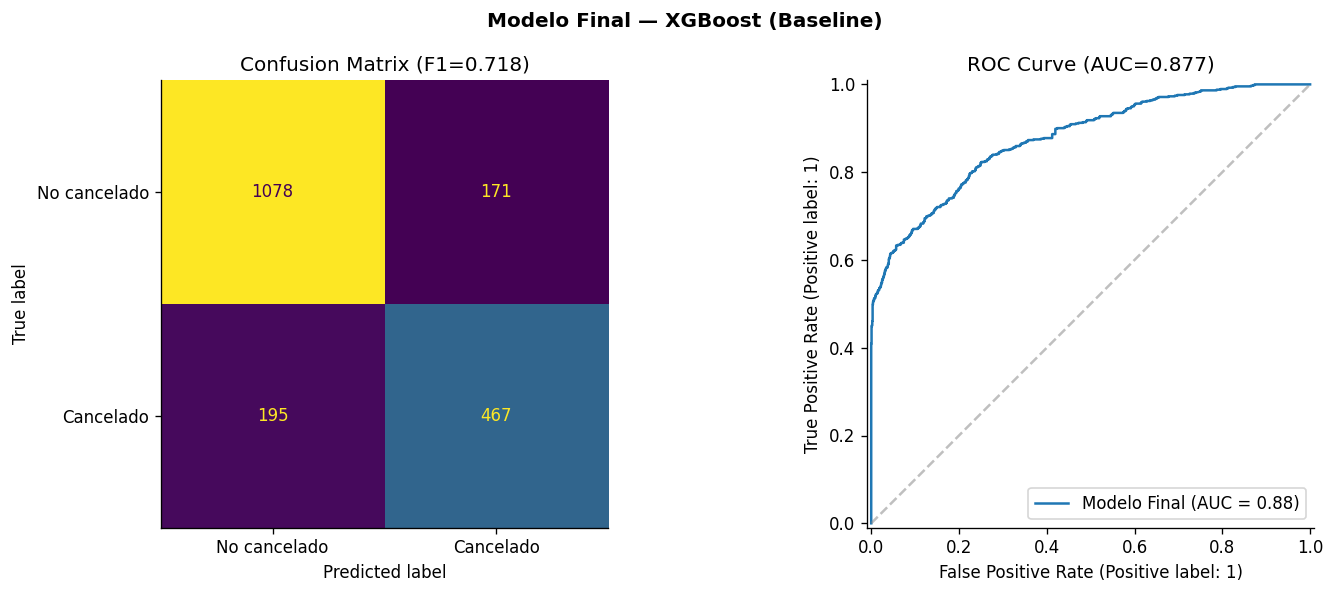

In [38]:
# Evaluación final en test (una sola vez, después de seleccionar estrategia por CV)
y_pred_final = final_pipe.predict(X_test)
y_prob_final = final_pipe.predict_proba(X_test)[:, 1]

final_f1  = f1_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_prob_final)
final_acc = accuracy_score(y_test, y_pred_final)

print("=" * 55)
print("EVALUACIÓN FINAL — MODELO SELECCIONADO")
print("=" * 55)
print(f"Modelo:    {best_info['model_name']}")
print(f"Estrategia:{final_label}")
print(f"Test F1:   {final_f1:.4f}")
print(f"Test AUC:  {final_auc:.4f}")
print(f"Test Acc:  {final_acc:.4f}")
print("")
print("Mejora vs baseline (selección por CV, evaluación única en test):")
print(f"  F1:  {final_f1 - best_info['test_f1']:+.4f}")
print(f"  AUC: {final_auc - best_info['test_roc_auc']:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Modelo Final — {best_info['model_name']} ({final_label})", fontsize=12, fontweight="bold")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, ax=axes[0], colorbar=False,
    display_labels=["No cancelado", "Cancelado"]
)
axes[0].set_title(f"Confusion Matrix (F1={final_f1:.3f})")

RocCurveDisplay.from_predictions(y_test, y_prob_final, ax=axes[1], name="Modelo Final")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
axes[1].set_title(f"ROC Curve (AUC={final_auc:.3f})")

plt.tight_layout()
plt.savefig("outputs/final_model_evaluation.png", bbox_inches="tight")
plt.show()


In [39]:
# Guardar modelo final
with open("data/processed/final_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipe, f)

with open("data/processed/final_feature_cols.txt", "w") as f:
    f.write("\n".join(feature_cols))

print("Modelo final guardado en data/processed/final_pipeline.pkl")

Modelo final guardado en data/processed/final_pipeline.pkl


## 5. Función predictora

La función `predictor_v1_Grupo_1()` recibe un DataFrame de nuevas reservas (mismas columnas
que el dataset original, **sin** la columna `canceled_job`) y devuelve un array de predicciones binarias.

Ver también el archivo `predictor.py` para la versión standalone importable.

In [40]:
def predictor_v1_Grupo_1(X_new: pd.DataFrame) -> np.ndarray:
    """
    Predice si una reserva GPU será cancelada antes de su ejecución.

    Args:
        X_new: DataFrame con las mismas columnas que gpu_resource_reservations.csv
               (puede o no incluir 'canceled_job'; se ignora si está presente)

    Returns:
        np.ndarray of int (0 = no cancelado, 1 = cancelado)
    """
    # Preprocessing: replica EXACTA de 01_limpieza.ipynb
    df_new = X_new.copy()

    # 1. Drop columnas derivadas/redundantes + target si viene
    for col in ["total_gpu_hours", "total_processes", "request_month", "canceled_job"]:
        if col in df_new.columns:
            df_new = df_new.drop(columns=[col])

    # 2. Encoding ciclico de request_week (igual que en train)
    df_new["week_sin"] = np.sin(2 * np.pi * df_new["request_week"] / 53)
    df_new["week_cos"] = np.cos(2 * np.pi * df_new["request_week"] / 53)

    # 3. One-Hot Encoding (drop_first=False + reindex: robusto a subconjuntos/categorias faltantes)
    cat_cols = df_new.select_dtypes(include="object").columns.tolist()
    df_new = pd.get_dummies(df_new, columns=cat_cols, drop_first=False, dtype=int)

    # 4. Alinear al espacio de features del modelo (añade faltantes=0, descarta extras y categoria base)
    df_new = df_new.reindex(columns=feature_cols, fill_value=0)

    # 5. Predicción
    return final_pipe.predict(df_new).astype(int)


# Test rápido de la función predictora
df_orig_sample = pd.read_csv("dataset/gpu_resource_reservations.csv").drop(columns=["canceled_job"])
sample_predictions = predictor_v1_Grupo_1(df_orig_sample.head(10))
print("Predicciones de prueba (primeras 10 filas):")
print(sample_predictions)
print(f"\n→ Función predictora operativa. Devuelve array de shape {sample_predictions.shape}")

Predicciones de prueba (primeras 10 filas):
[0 1 0 1 1 0 0 1 0 0]

→ Función predictora operativa. Devuelve array de shape (10,)


## 6. Conclusiones

### Model-centered vs Data-centered

El enfoque model-centered estableció un baseline sólido mediante:
- Selección del mejor clasificador entre 5 alternativas con tuning de hiperparámetros
- Validación temporal (TimeSeriesSplit) para evitar leakage cronológico

El enfoque data-centered reveló que:
- El rendimiento global oculta heterogeneidad significativa entre cohortes
- Ciertas combinaciones (client_type × service_tier) presentan tasas de error mucho más altas
- Las curvas de aprendizaje indican si el sistema es datos-limitado o modelo-limitado

### Riesgos identificados
- **Leakage temporal:** controlado con split y CV cronológicos
- **SMOTE:** interpolación puede generar casos irreales si la cohorte es internamente heterogénea
- **Sesgo de representación:** cohortes pequeñas tienen alta varianza en sus métricas

### Mejoras futuras
- Solicitar datos adicionales de las cohortes más problemáticas
- Feature engineering temporal más sofisticado (lag features, rolling statistics)
- Modelos específicos por cohorte (ensemble especializado)
- Optimización del umbral de decisión por cohorte según costo operativo